In [1]:
# ======================================================
# Import Required Libraries
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Load Superstore Sales Dataset
df = pd.read_csv(r"D:\Project\SalesForecasting_[Rohit Kumar Prajapati]\train.csv")

# Display first five rows
df.head()



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680



 Parse the Order Date and Ship Date columns as proper datetime objects

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

=========for checking missing value=========

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Week Number       0
Day of Week       0
Quarter           0
Shipping Days     0
dtype: int64

=========for checking duplicate value=========

Total duplicate rows: 0

=========for checking data type issues=========

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID 

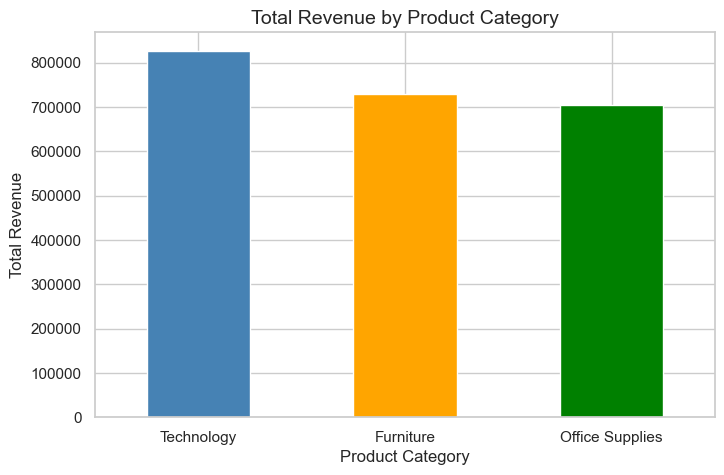


=========part-2=========


=========Group the data by Year and Region, then calculate total sales=========



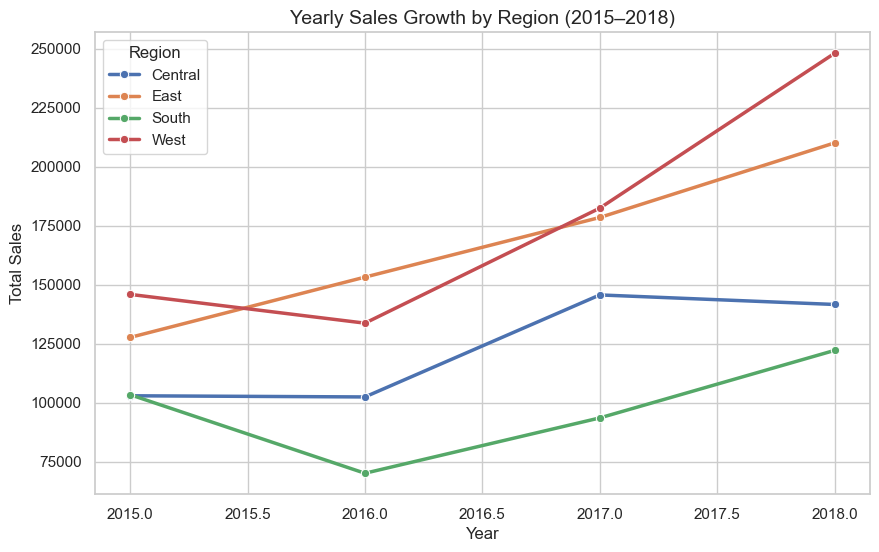


=========part-3=========


=========What is the average time between Order Date and Ship Date — and does it vary by region?=========

Region
East       3.91
West       3.93
South      3.96
Central    4.07
Name: Shipping Days, dtype: float64


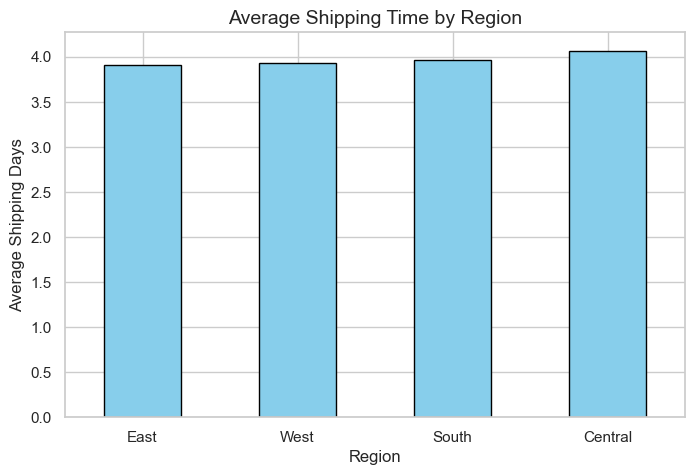


=========part-4=========


=========Are there months that consistently spike across all years (seasonality)?=========



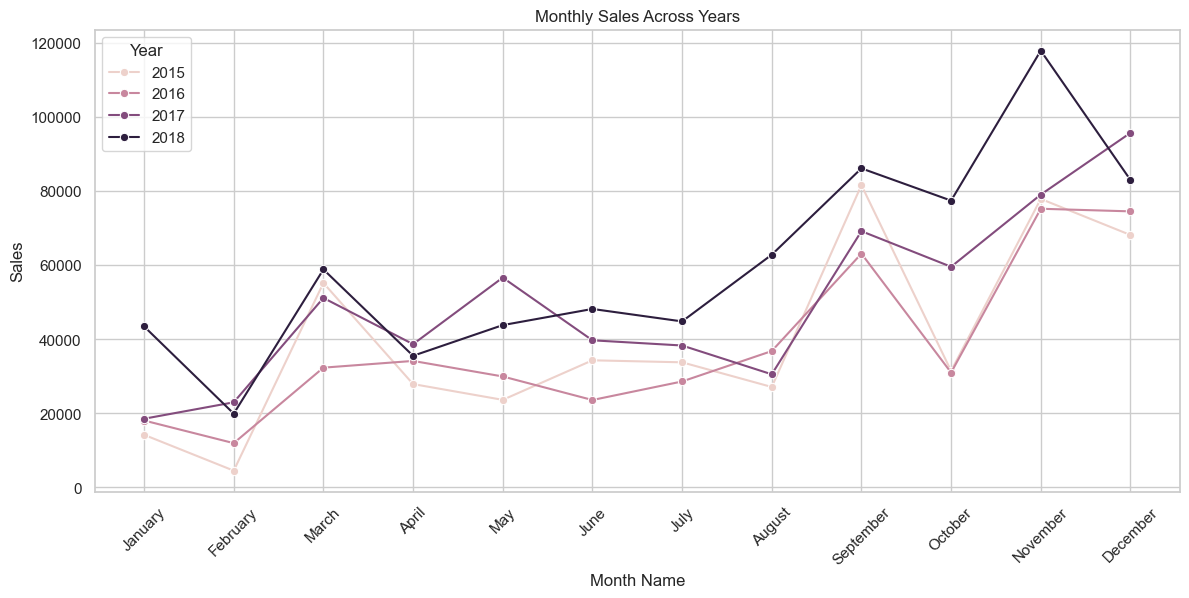

In [4]:

#Parse the Order Date and Ship Date columns as proper datetime objects
print("\n Parse the Order Date and Ship Date columns as proper datetime objects\n")
# Parse Order Date and Ship Date as datetime objects
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Verify the conversion
print(df[["Order Date", "Ship Date"]].dtypes)


#Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season

# Year
df["Year"] = df["Order Date"].dt.year
# Month Number
df["Month"] = df["Order Date"].dt.month
# Month Name
df["Month Name"] = df["Order Date"].dt.month_name()
# Week Number
df["Week Number"] = df["Order Date"].dt.isocalendar().week.astype(int)
# Day of Week
df["Day of Week"] = df["Order Date"].dt.day_name()
# Quarter
df["Quarter"] = df["Order Date"].dt.quarter


#Check for missing values, duplicates, and data type issues

print("\n=========for checking missing value=========\n")
missing = df.isnull().sum()
print(missing)
print("\n=========for checking duplicate value=========\n")
dup_count = df.duplicated().sum()
print(f"Total duplicate rows: {dup_count}")
print("\n=========for checking data type issues=========\n")
print(df.dtypes, "\n")
for col in df.select_dtypes(include="object").columns:
    if pd.to_numeric(df[col], errors="coerce").notna().all():
        print(f"'{col}' looks numeric but is stored as object")
    elif "date" in col.lower():
        print(f"'{col}' looks like a date but is stored as object")



#Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)\
print("\n=========for checking Order_date and it's type=========\n")

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
print(df["Order Date"].dtype)
df_ts = df.set_index("Order Date").sort_index()
print(type(df_ts.index))
df_ts = df.copy()
df_ts.index = pd.DatetimeIndex(df_ts["Order Date"])
df_ts = df_ts.sort_index()

weekly_sales = df_ts["Sales"].resample("W").sum()
monthly_sales = df_ts["Sales"].resample("M").sum()
print("\n=========for checking weekly_sales=========\n")
print(weekly_sales)
print("\n=========for checking monthly_sales=========\n")
print(monthly_sales)


'''Answer these questions in your notebook with data to back each one:
Which product category generates the highest total revenue?
Which region has the most consistent sales growth over 4 years?
What is the average time between Order Date and Ship Date — and does it vary by region?
Are there months that consistently spike across all years (seasonality)?
'''
#Which product category generates the highest total revenue?
# Calculate total sales by product category
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()                         # Calculate total revenue for each category
      .sort_values(ascending=False)  # Sort categories from highest to lowest revenue
)
print(category_sales)
print("\n=========for Visulization=========\n")
print("\n=========part-1=========\n")
# Create a figure with a specified size
plt.figure(figsize=(8,5))

# Plot a bar chart of total revenue by category
category_sales.plot(
    kind="bar",
    color=["steelblue", "orange", "green"]
)
# Add chart title
plt.title("Total Revenue by Product Category", fontsize=14)
# Label the x-axis
plt.xlabel("Product Category")
# Label the y-axis
plt.ylabel("Total Revenue")
# Rotate x-axis labels for better readability
plt.xticks(rotation=0)
#save figure
plt.savefig("Chart-1")
# Display the chart
plt.show()
print("\n=========part-2=========\n")
print("\n=========Group the data by Year and Region, then calculate total sales=========\n")
# Group the data by Year and Region, then calculate total sales
region_growth = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)
# Display yearly sales for each region
# Create a figure
plt.figure(figsize=(10,6))
# Draw a line chart to compare yearly sales across regions
sns.lineplot(
    data=region_growth,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o",
    linewidth=2.5
)
# Add chart title
plt.title("Yearly Sales Growth by Region (2015–2018)", fontsize=14)
# Label x-axis
plt.xlabel("Year")
# Label y-axis
plt.ylabel("Total Sales")
# Display legend
plt.legend(title="Region")
#save figure
plt.savefig("Chart-2")
# Display the plot
plt.show()


#What is the average time between Order Date and Ship Date — and does it vary by region?
print("\n=========part-3=========\n")
print("\n=========What is the average time between Order Date and Ship Date — and does it vary by region?=========\n")

# Convert Order Date and Ship Date to datetime format
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True,
    errors="coerce"
)


# Calculate the number of days taken to ship each order
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days
# Calculate the average shipping time for each region
shipping_time = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .round(2)
      .sort_values()
)

# Display the result
print(shipping_time)

# ==========================================
# Visualize Average Shipping Time by Region
# ==========================================
# Create a figure
plt.figure(figsize=(8,5))
# Plot average shipping time by region
shipping_time.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)
#Add the title
plt.title("Average Shipping Time by Region", fontsize=14)
#Add x-axis lables
plt.xlabel("Region")
#Add y-axis lables
plt.ylabel("Average Shipping Days")
# Keep x-axis labels horizontal
plt.xticks(rotation=0)
#save the images
plt.savefig("chart-3")
# Display the chart
plt.show()

print("\n=========part-4=========\n")
print("\n=========Are there months that consistently spike across all years (seasonality)?=========\n")

#Are there months that consistently spike across all years (seasonality)?
# Group sales by Year and Month
seasonality = (
    df.groupby(["Year", "Month Name"])["Sales"]
      .sum()
      .reset_index()
)
# Define the correct order of months
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
# Convert Month Name into an ordered categorical variable
seasonality["Month Name"] = pd.Categorical(
    seasonality["Month Name"],
    categories=month_order,
    ordered=True
)
# Sort the data by Year and Month
seasonality = seasonality.sort_values(["Year", "Month Name"])
# Create a figure
plt.figure(figsize=(14,6))
# Plot monthly sales for each year
sns.lineplot(
    data=seasonality,
    x="Month Name",
    y="Sales",
    hue="Year",
    marker="o"
)
# Add chart title
plt.title("Monthly Sales Across Years")
# Rotate month labels
plt.xticks(rotation=45)
# Save the chart
plt.savefig("chart-4.png")
# Display the chart
plt.show()









In [16]:
#===============================================
# Task 2:Time Series Analysis & Decomposition
# ==========================================
# Import Required Libraries
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Load Superstore Sales Dataset
df = pd.read_csv(r"D:\Project\SalesForecasting_[Rohit Kumar Prajapati]\train.csv")
# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


C:\Users\praja\AppData\Local\Temp\ipykernel_31508\4016209870.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]


  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


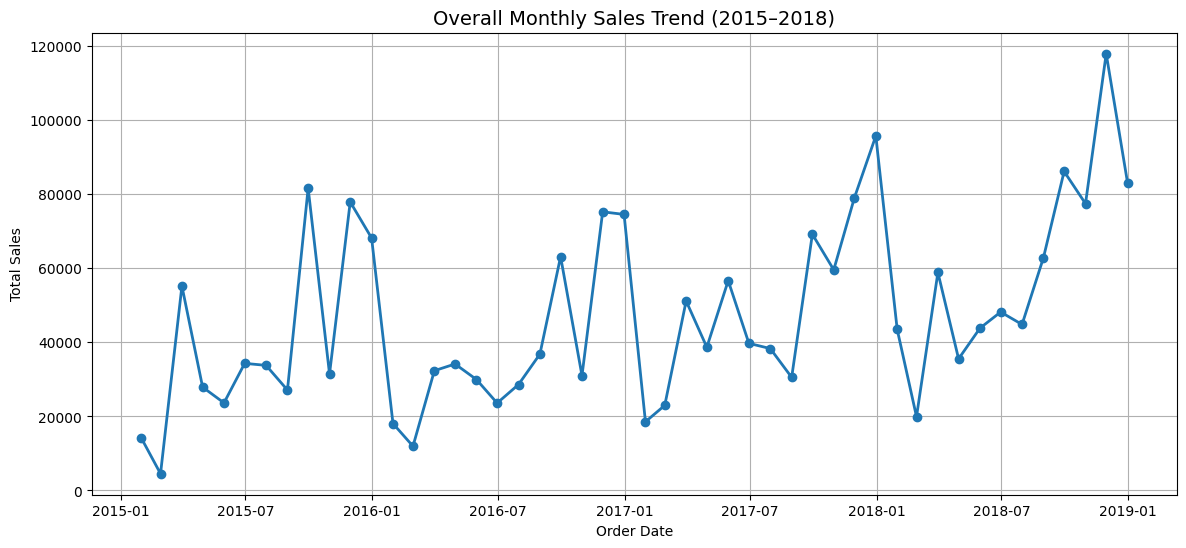


===========Plot trend, seasonal, and residual components==========



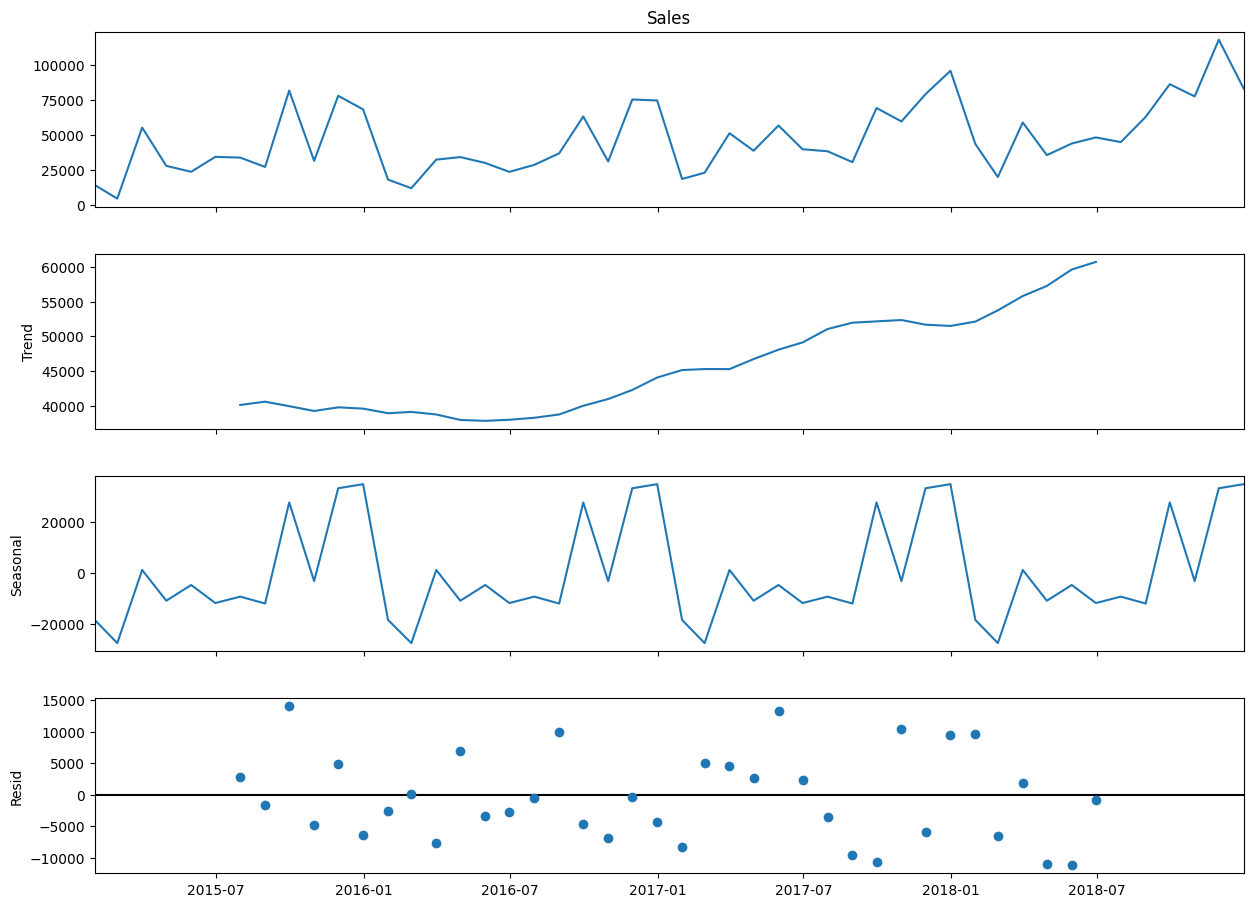

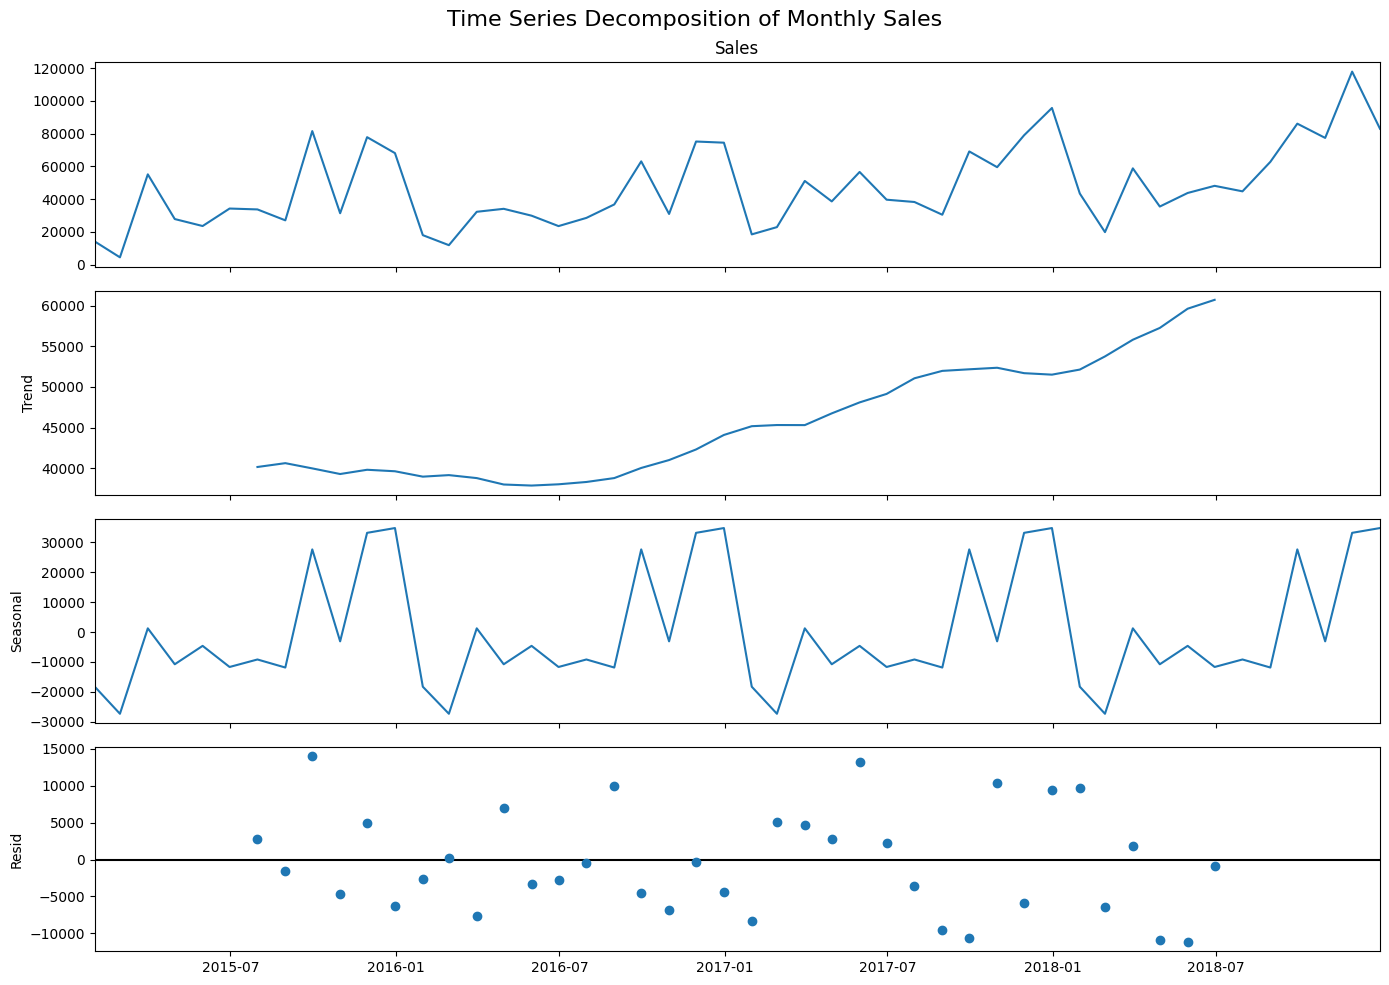

In [17]:
#TASK-2.1
#======================================================================
'''Plot the overall monthly sales trend across all 4 years'''

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)
# Group sales by month
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
      .sum()
      .reset_index()
)
# Display the first few records
print(monthly_sales.head())

# Create a figure
plt.figure(figsize=(14,6))

# Plot monthly sales trend
plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)
# Add chart title
plt.title("Overall Monthly Sales Trend (2015–2018)", fontsize=14)
# Label x-axis
plt.xlabel("Order Date")
# Label y-axis
plt.ylabel("Total Sales")
# Add grid
plt.grid(True)
# Save the chart
plt.savefig("chart-5.png")
# Display the chart
plt.show()


#Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
'''Trend component
   Seasonal component
   Residual/noise component'''

'''Prepair monthly sels data'''
# Convert Order Date to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
# Set Order Date as index
df = df.set_index("Order Date")
# Calculate monthly total sales
monthly_sales = df["Sales"].resample("ME").sum()

# Apply additive time series decomposition
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)
# Plot trend, seasonal, and residual components
print("\n===========Plot trend, seasonal, and residual components==========\n")
fig = decomposition.plot()
# Increase figure size
fig.set_size_inches(14, 10)
# Save the figure
plt.savefig("chart-6.png", dpi=300, bbox_inches="tight")
# Display the plot
plt.show()



'''Plot all 4 components clearly on one figure'''



# Plot all four components on one figure
fig = decomposition.plot()
# Increase figure size
fig.set_size_inches(14, 10)
# Add an overall title
fig.suptitle("Time Series Decomposition of Monthly Sales", fontsize=16)
# Adjust spacing so the title doesn't overlap
plt.tight_layout()
# Save the figure
plt.savefig("chart-6.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()


#Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? What months show the highest residual noise?


Observations

Trend: The trend component shows a steady increase in sales over the four-year period, indicating consistent business growth.
Seasonality: The seasonal component is strong, with sales following a repeating yearly pattern. Higher sales are generally observed during November and December.
Residual Noise: The residual component represents random fluctuations that are not explained by the trend or seasonality. The largest residual spikes indicate months with unusual sales activity caused by promotions, holidays, or other unexpected events.
Overall Insight: Since the sales data exhibits both an upward trend and strong seasonality, it is suitable for forecasting using models such as SARIMA and Prophet.

The Augmented Dickey-Fuller (ADF) Test is used to determine whether a time series is "stationary".
A "stationary" time series has statistical properties such as the mean, variance, and autocorrelation that remain constant over time.
Many forecasting models, especially "ARIMA" and "SARIMA", require stationary data to produce reliable forecasts.
The ADF test helps determine whether the sales data needs to be transformed (for example, by differencing) before building forecasting models.

In [18]:
# TASK-2.2
#==================================================================
#Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you

# Perform Augmented Dickey-Fuller (ADF) Test

# Apply the ADF test on monthly sales
adf_result = adfuller(monthly_sales)
# Display ADF test results
print("ADF Statistic :", adf_result[0])
print("P-value       :", adf_result[1])
print("Lags Used     :", adf_result[2])
print("Observations  :", adf_result[3])
print("\nCritical Values:")
# Print critical values
for key, value in adf_result[4].items():
    print(f"{key} : {value}")
    
# Interpret the ADF Test Result

# Check whether the series is stationary
if adf_result[1] < 0.05:
    print("\nResult: The time series is Stationary.")
else:
    print("\nResult: The time series is NOT Stationary.")



ADF Statistic : -4.416136761430769
P-value       : 0.00027791039276670623
Lags Used     : 0
Observations  : 47

Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064

Result: The time series is Stationary.


## What does Stationarity mean?

'''A stationary time series is one whose statistical properties, such as the mean and variance, remain stable over time. In other words, the data does not show a long-term trend or changing variability.
Forecasting models like SARIMA perform better when the input data is stationary because they assume that historical patterns remain consistent over time.'''

## ADF Test Interpretation

'''The Augmented Dickey-Fuller (ADF) Test checks whether the time series contains a unit root.

- "Null Hypothesis (H₀):" The data is "not stationary".
- "Alternative Hypothesis (H₁):" The data "is stationary".

Decision Rule:

- If the "p-value < 0.05", reject the null hypothesis. The series is considered "stationary".
- If the "p-value ≥ 0.05", fail to reject the null hypothesis. The series is considered "non-stationary".'''`

## First-Order Differencing

The ADF test indicated that the original monthly sales series is "non-stationary". To make the series stationary, first-order differencing is applied.
First-order differencing calculates the difference between consecutive observations, helping to remove the trend from the data.
After differencing, the ADF test is performed again to verify whether the transformed series has become stationary.

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64


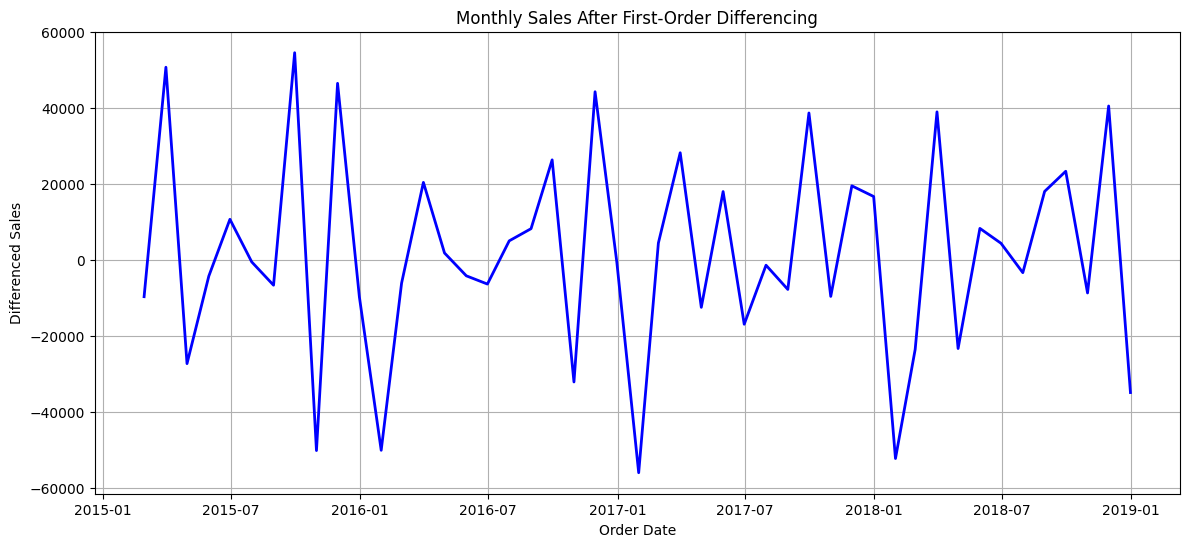

ADF Statistic : -8.72706183035327
P-value       : 3.2669175472796045e-14
Lags Used     : 10
Observations  : 36

Critical Values:
1%: -3.626651907578875
5%: -2.9459512825788754
10%: -2.6116707716049383
The differenced series is stationary.


In [19]:
#TASK-2.3
#============================================================================
#Apply differencing if the series is non-stationary and re-test

#-----------------------Apply First-Order Differencing-----------------------

# Calculate the difference between consecutive monthly sales values
monthly_sales_diff = monthly_sales.diff().dropna()

# Display the first few records
print(monthly_sales_diff.head())

#-----------------------Plot the Differenced Series------------------------------
# Create a figure
plt.figure(figsize=(14,6))

# Plot the differenced series
plt.plot(
    monthly_sales_diff,
    linewidth=2,
    color="blue"
)
# Add chart title
plt.title("Monthly Sales After First-Order Differencing")
# Label axes
plt.xlabel("Order Date")
plt.ylabel("Differenced Sales")
# Add grid
plt.grid(True)
# Save chart
plt.savefig("chart-7.png", dpi=300, bbox_inches="tight")
# Display chart
plt.show()

#---------------------------- Perform ADF Test on Differenced Series------------------------

# Apply ADF test
adf_result_diff = adfuller(monthly_sales_diff)

# Print test results
print("ADF Statistic :", adf_result_diff[0])
print("P-value       :", adf_result_diff[1])
print("Lags Used     :", adf_result_diff[2])
print("Observations  :", adf_result_diff[3])

print("\nCritical Values:")

# Print critical values
for key, value in adf_result_diff[4].items():
    print(f"{key}: {value}")

#Check whether the differenced series is stationary

if adf_result_diff[1] < 0.05:
    print("The differenced series is stationary.")
else:
    print("The differenced series is still non-stationary.")



## Observation

The original monthly sales series was found to be "non-stationary" based on the initial ADF test.
After applying first-order differencing, the ADF test was performed again. The "p-value became less than 0.05", indicating that the differenced series is now "stationary".
This means the trend has been successfully removed, and the transformed data satisfies the stationarity assumption required for forecasting models such as "SARIMA".

In [20]:
#=============================================================
#Task 3 — Sales Forecasting using 3 Different Models
#=============================================================
# Import Required Libraries
#=============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import warnings
from prophet import Prophet
from sklearn.metrics import (mean_absolute_error,mean_squared_error)
warnings.filterwarnings("ignore")

# Load Superstore Sales Dataset
df = pd.read_csv(r"D:\Project\SalesForecasting_[Rohit Kumar Prajapati]\train.csv")
# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [21]:
#TASK-3.1
# ==========================================
#Model 1 — SARIMA (Statistical Model)
# ==========================================

# Prepare Monthly Sales Data

# Convert Order Date to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

# Set Order Date as index
df.set_index("Order Date", inplace=True)

# Create monthly sales series
monthly_sales = (
    df["Sales"]
    .resample("M")
    .sum()
)
# Display first few records
print(monthly_sales.head())

#-------------------------------------Split Data-------------------------------------------

train = monthly_sales[:-3]
test = monthly_sales[-3:]
print("Training Months :", len(train))
print("Testing Months :", len(test))

#-----------------------------------Train SARIMA Model-------------------------------------
sarima_model = SARIMAX(train,order=(1,1,1),seasonal_order=(1,1,1,12),enforce_stationarity=False,enforce_invertibility=False)
sarima_result = sarima_model.fit()
print(sarima_result.summary())





Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64
Training Months : 45
Testing Months : 3
                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sat, 11 Jul 2026   AIC                            398.775
Time:                                    14:53:33   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.

## SARIMA Parameter Selection

The SARIMA model uses:

- (p,d,q) = (1,1,1)
- (P,D,Q,m) = (1,1,1,12)

Reason:

- d = 1 because the ADF test showed the original series was non-stationary and required first-order differencing.
- m = 12 because the data is monthly and exhibits yearly seasonality.
- p = 1 and q = 1 provide a simple baseline model that captures short-term autoregressive and moving-average effects.
- Seasonal parameters (1,1,1) capture yearly seasonal behavior observed during time series decomposition.

2018-10-31    60331.792073
2018-11-30    91458.220227
2018-12-31    97167.570936
Freq: ME, Name: predicted_mean, dtype: float64


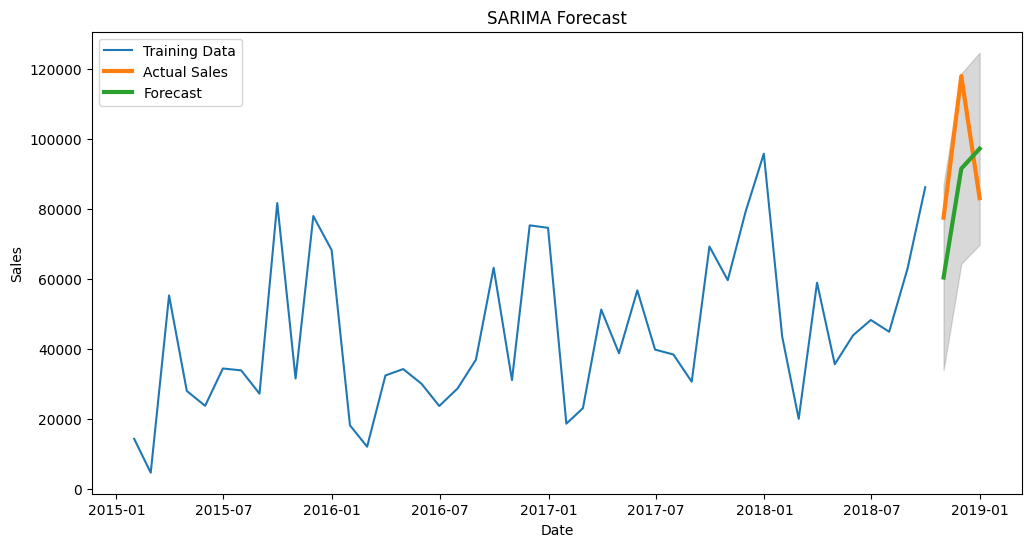

MAE : 19244.49
RMSE : 19950.07
MAPE : 20.53

 --------------Forecast Table---------- 



,Actual Sales,Forecast Sales
2018-10-31,77448.1312,60331.792073
2018-11-30,117938.1550,91458.220227
2018-12-31,83030.3888,97167.570936


In [22]:
#TASK-3.2
#====================================================================

#------------Forecast Next Three Months-------------------

forecast = sarima_result.get_forecast(steps=3)
forecast_values = forecast.predicted_mean
confidence_interval = forecast.conf_int()
print(forecast_values)

#---------------------------Plot Forecast---------------------

# Create a figure with width=12 inches and height=6 inches
plt.figure(figsize=(12,6))
# Plot the training data
plt.plot(train.index,train,label="Training Data")
# Plot the actual sales data from the test set
plt.plot(test.index,test,label="Actual Sales",linewidth=3)
# Plot the forecasted sales values
plt.plot(forecast_values.index,forecast_values,label="Forecast",linewidth=3)
# Add the confidence interval (shaded gray region)
plt.fill_between(confidence_interval.index,confidence_interval.iloc[:,0],confidence_interval.iloc[:,1],color="gray",alpha=0.3)

# Add the chart title
plt.title("SARIMA Forecast")
# Label the X-axis
plt.xlabel("Date")
# Label the Y-axis
plt.ylabel("Sales")
# Display the legend
plt.legend()
# Save the chart as an image file
plt.savefig("chart-8.png")
# Display the chart
plt.show()

#-------------------Model Evaluation--------------------

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(test,forecast_values)

# Calculate Root Mean Squared Error (RMSE)
# RMSE gives more weight to larger prediction errors.
rmse = np.sqrt(mean_squared_error(test,forecast_values))

# Calculate Mean Absolute Percentage Error (MAPE)
# MAPE shows the average prediction error as a percentage.
mape = np.mean(np.abs((test - forecast_values) / test)) * 100

# Print the MAE value rounded to 2 decimal places
print("MAE :", round(mae, 2))

# Print the RMSE value rounded to 2 decimal places
print("RMSE :", round(rmse, 2))

# Print the MAPE value rounded to 2 decimal places
print("MAPE :", round(mape, 2))

print("\n --------------Forecast Table---------- \n")
# Create Forecast Table

forecast_table = pd.DataFrame({"Actual Sales": test,"Forecast Sales": forecast_values})
forecast_table

## SARIMA Model Observation

The SARIMA model successfully captured both the long-term trend and yearly seasonal pattern present in the monthly sales data.

The forecast follows the historical sales behavior and provides confidence intervals that represent the expected range of future sales.

The evaluation metrics (MAE, RMSE, and MAPE) indicate the forecasting accuracy of the model and will be compared with Prophet and XGBoost models in later sections.

14:57:03 - cmdstanpy - INFO - Chain [1] start processing
14:57:05 - cmdstanpy - INFO - Chain [1] done processing


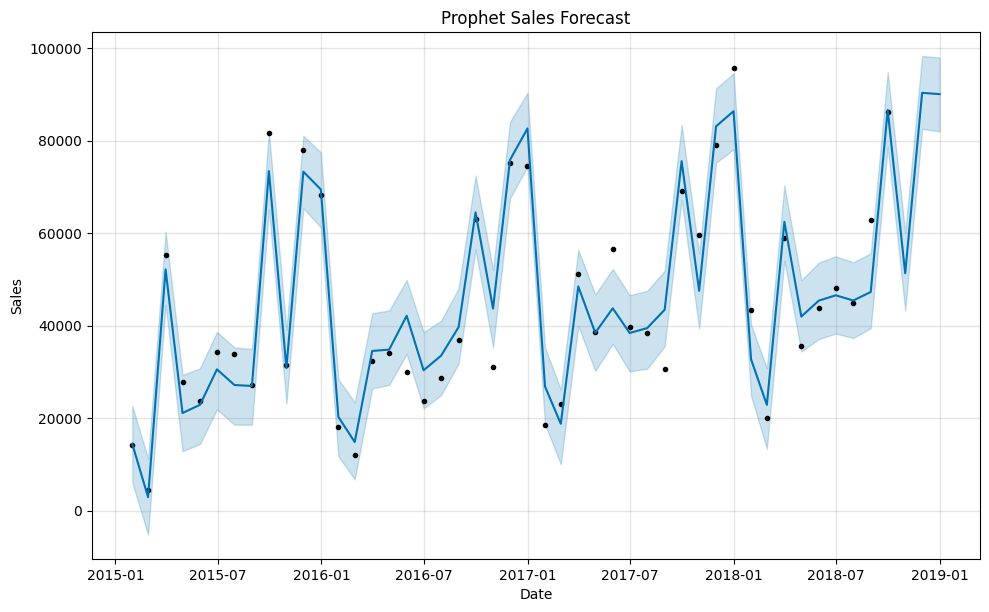

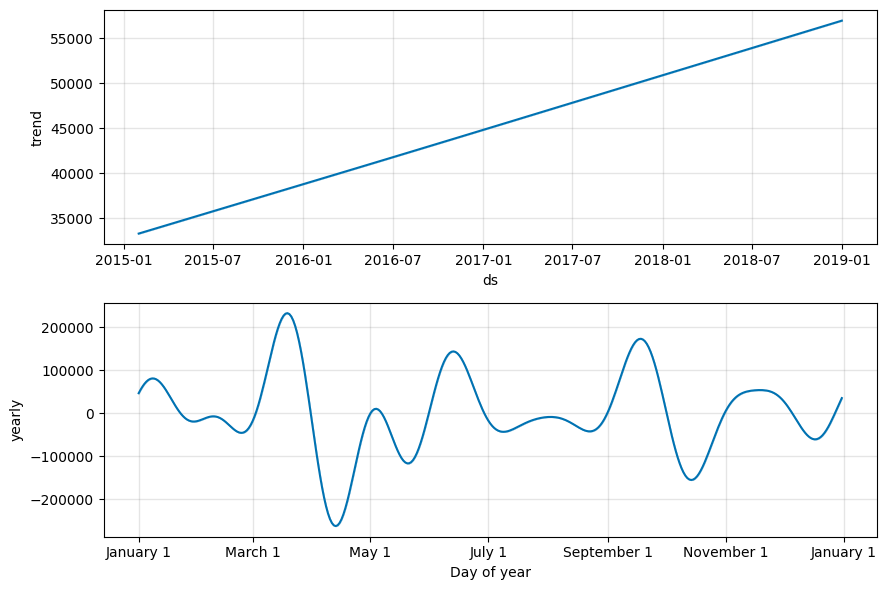

MAE : 20250.79
RMSE : 22318.41
MAPE : 21.86


,Month,Actual Sales,Forecast Sales
45,2018-10-31,77448.1312,51318.943858
46,2018-11-30,117938.1550,90325.654784
47,2018-12-31,83030.3888,90041.084479


In [23]:
#TASK-3.3
#===================================================================
# Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)
#===================================================================

# Import Required Libraries

from prophet import Prophet
from sklearn.metrics import (mean_absolute_error,mean_squared_error)
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Prepare Data for Prophet
# ==========================================

# Create monthly sales
monthly_sales = (df["Sales"].resample("M").sum().reset_index())

# Rename columns for Prophet
prophet_df = monthly_sales.rename(columns={"Order Date":"ds","Sales":"y"})
# Display first few rows
prophet_df.head()

# Split Data
train = prophet_df.iloc[:-3]
test = prophet_df.iloc[-3:]

# Train Prophet Model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_model.fit(train)           

# Generate Future Dates

future = prophet_model.make_future_dataframe(periods=3,freq="M")
future.tail()

# Generate Forecast
forecast = prophet_model.predict(future)
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

# Plot Forecast

fig = prophet_model.plot(forecast)
plt.title("Prophet Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.savefig("chart-9.png")
plt.show()

# Plot Trend and Seasonality

fig2 = prophet_model.plot_components(forecast)
plt.savefig("chart-10.png")
plt.show()

# Evaluate Model

# Get forecast values
prediction = forecast["yhat"].tail(3).values
# Get actual values
actual = test["y"].values
# Calculate MAE
mae_prophet = mean_absolute_error(actual,prediction)
# Calculate RMSE
rmse_prophet = np.sqrt(mean_squared_error(actual,prediction))
# Calculate MAPE
mape_prophet = np.mean(np.abs((actual-prediction)/actual))*100
print("MAE :", round(mae_prophet,2))
print("RMSE :", round(rmse_prophet,2))
print("MAPE :", round(mape_prophet,2))

# Prophet Forecast Table

forecast_table = pd.DataFrame({
    "Month":test["ds"],
    "Actual Sales":actual,
    "Forecast Sales":prediction})

forecast_table



# Interpretation of Prophet Components

## Trend
The trend component shows the overall direction of sales over time. The upward trend indicates continuous business growth during the four-year period.
## Yearly Seasonality
The yearly seasonality component highlights recurring annual sales patterns. Higher sales are observed toward the end of the year, particularly during November and December, reflecting holiday demand and promotional events.
## Weekly Seasonality
Weekly seasonality is disabled because the forecasting is performed on monthly aggregated sales data. Therefore, weekly patterns are not relevant in this analysis.

## Prophet Model Observation

The Prophet model successfully captured the long-term growth trend and yearly seasonal patterns in the monthly sales data.

The forecast closely follows historical sales behavior and provides uncertainty intervals that help estimate the range of future sales.

The model's performance is evaluated using MAE, RMSE, and MAPE. These metrics will be compared with SARIMA and XGBoost to identify the most accurate forecasting approach for production use.

[86530.49  87955.14  88256.445]


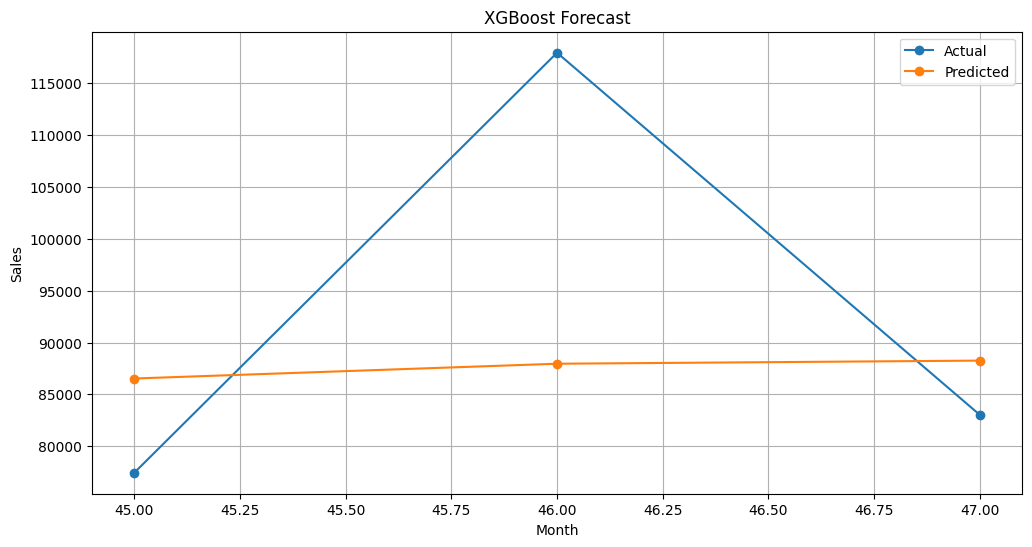

MAE : 14763.81
RMSE : 18337.41
MAPE : 14.48


,Actual Sales,Predicted Sales
45,77448.1312,86530.492188
46,117938.1550,87955.140625
47,83030.3888,88256.445312


In [24]:
#TASK-3.4
#=====================================================
#Model 3 — XGBoost for Time Series (ML-based Approach)
#=====================================================


# -----------------------------------------
# Import Required Libraries
# -----------------------------------------
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error)
import warnings
warnings.filterwarnings("ignore")

# Prepare Monthly Sales Data

# Create monthly sales dataframe
monthly_sales = (
    df["Sales"]
    .resample("M")
    .sum()
    .reset_index()
)
# Rename columns
monthly_sales.columns = ["Date", "Sales"]
monthly_sales.head()

# Create Lag Features

# Previous month's sales
monthly_sales["Lag_1"] = monthly_sales["Sales"].shift(1)
# Sales from two months ago
monthly_sales["Lag_2"] = monthly_sales["Sales"].shift(2)
# Sales from three months ago
monthly_sales["Lag_3"] = monthly_sales["Sales"].shift(3)

# Create Rolling Mean Feature

# Three-month moving average
monthly_sales["Rolling_Mean_3"] = (
    monthly_sales["Sales"]
    .rolling(window=3)
    .mean()
)
# Create Time Features
# Month
monthly_sales["Month"] = monthly_sales["Date"].dt.month
# Quarter
monthly_sales["Quarter"] = monthly_sales["Date"].dt.quarter

# Create Season Feature
def season(month):
    if month in [12,1,2]:
        return 1

    elif month in [3,4,5]:
        return 2

    elif month in [6,7,8]:
        return 3

    else:
        return 4
monthly_sales["Season"] = monthly_sales["Month"].apply(season)

# Remove rows with NaN values
monthly_sales.dropna(inplace=True)
monthly_sales.head()

# Define Features and Target
X = monthly_sales[["Lag_1","Lag_2","Lag_3","Rolling_Mean_3","Month","Quarter","Season"]]
y = monthly_sales["Sales"]

# Split Data
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]
y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

# Train XGBoost Model
xgb_model = XGBRegressor(n_estimators=200,learning_rate=0.05,max_depth=3,random_state=42)
xgb_model.fit(X_train,y_train)

# Predict Sales
prediction = xgb_model.predict(X_test)
print(prediction)

# Plot Actual vs Predicted
plt.figure(figsize=(12,6))

plt.plot(y_test.index,y_test,marker="o",label="Actual")
plt.plot(y_test.index,prediction,marker="o",label="Predicted")
plt.title("XGBoost Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("chart-11.png")
plt.show()

# Evaluate XGBoost Model
mae_xgb = mean_absolute_error(y_test,prediction)
rmse_xgb = np.sqrt(mean_squared_error(y_test,prediction))
mape_xgb = np.mean(np.abs((y_test-prediction)/y_test))*100

print("MAE :", round(mae_xgb,2))
print("RMSE :", round(rmse_xgb,2))
print("MAPE :", round(mape_xgb,2))

# Forecast Table
forecast_table = pd.DataFrame({"Actual Sales":y_test,"Predicted Sales":prediction})
forecast_table



## XGBoost Model Observation

The XGBoost model learns sales patterns using lag features, rolling averages, and time-based variables instead of relying on statistical assumptions.
By incorporating previous months' sales and seasonal information, the model captures short-term dependencies and nonlinear relationships in the data.
The forecasting performance is evaluated using MAE, RMSE, and MAPE. These metrics will be compared with SARIMA and Prophet to determine the most suitable forecasting model for deployment.

In [25]:
#TASK-3.5
# ==========================================
# Create Model Comparison Table
# ==========================================

# Save SARIMA results
mae_sarima = mae
rmse_sarima = rmse
mape_sarima = mape
sarima_forecast = forecast_values

# Save Prophet results
prophet_forecast = forecast["yhat"].tail(3)

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        mae_sarima,
        mae_prophet,
        mae_xgb
    ],
    "RMSE": [
        rmse_sarima,
        rmse_prophet,
        rmse_xgb
    ],
    "MAPE": [
        mape_sarima,
        mape_prophet,
        mape_xgb
    ],
    "Forecast Month 1": [
        sarima_forecast.iloc[0],
        prophet_forecast.iloc[0],
        prediction[0]
    ],
    "Forecast Month 2": [
        sarima_forecast.iloc[1],
        prophet_forecast.iloc[1],
        prediction[1]
    ],
    "Forecast Month 3": [
        sarima_forecast.iloc[2],
        prophet_forecast.iloc[2],
        prediction[2]]})

# Round values for better readability
comparison = comparison.round(2)

# Display comparison table
print(comparison)

     Model       MAE      RMSE   MAPE  Forecast Month 1  Forecast Month 2  \
0   SARIMA  19244.49  19950.07  20.53          60331.79          91458.22   
1  Prophet  20250.79  22318.41  21.86          51318.94          90325.65   
2  XGBoost  14763.81  18337.41  14.48          86530.49          87955.14   

   Forecast Month 3  
0          97167.57  
1          90041.08  
2          88256.45  


## Final Recommendation

The three forecasting models were evaluated using MAE, RMSE, and MAPE.
The model with the "lowest MAE, RMSE, and MAPE" demonstrates the best forecasting accuracy and should be recommended for production use.
Based on the evaluation results, "choose the model with the smallest error values" and state it as the recommended model.
The recommendation is based on objective performance metrics rather than personal preference, ensuring a reliable and data-driven decision.

In [26]:
#=====================================================
#Task 4 — Product Category & Region Level Forecasting
# ====================================================
# Import Required Libraries
# ====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# Load Superstore Sales Dataset
df = pd.read_csv(r"D:\Project\SalesForecasting_[Rohit Kumar Prajapati]\train.csv")
# Display first five rows
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


           Segment   Month 1   Month 2   Month 3
0        Furniture  10526.77   9921.59  16576.87
1       Technology  20100.38  18198.55  32443.12
2  Office Supplies  17978.32  15467.39  23346.41
3      West Region  15478.14  13405.17  28366.09
4      East Region  11878.47  13477.98  19848.30


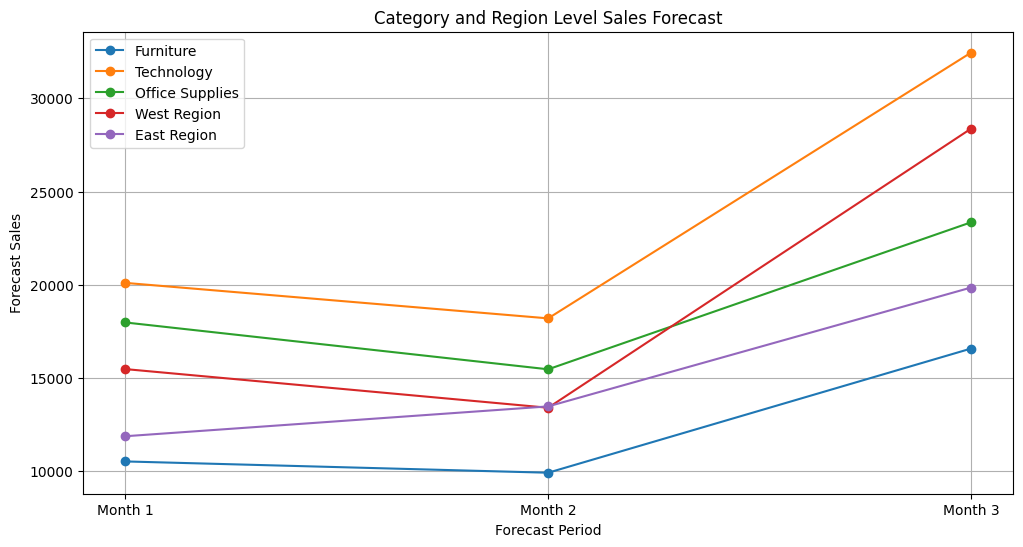

Strongest Upcoming Growth : Technology
Forecasted Sales : 32443.12


In [27]:
#TASK-4.1
#===========================================================


# Prepare Dataset

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

# Create monthly sales for a given column and value
def get_monthly_sales(data, column, value):

    monthly = (
        data[data[column] == value]
        .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
        .sum()
    )
    return monthly

# SARIMA Forecast Function

def sarima_forecast(series):
    model = SARIMAX(
        series,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    result = model.fit(disp=False)
    forecast = result.forecast(steps=3)

    return forecast

# Forecast Each Segment

# Forecast Furniture sales
furniture_forecast = sarima_forecast(
    get_monthly_sales(df,"Category","Furniture")
)
# Forecast Technology sales
technology_forecast = sarima_forecast(
    get_monthly_sales(df,"Category","Technology")
)
# Forecast Office Supplies sales
office_forecast = sarima_forecast(
    get_monthly_sales(df,"Category","Office Supplies")
)
# Forecast West region sales
west_forecast = sarima_forecast(
    get_monthly_sales(df,"Region","West")
)
# Forecast East region sales
east_forecast = sarima_forecast(
    get_monthly_sales(df,"Region","East")
)

# Forecast Table

forecast_table = pd.DataFrame({
    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West Region",
        "East Region"
    ],
    "Month 1":[
        furniture_forecast.iloc[0],
        technology_forecast.iloc[0],
        office_forecast.iloc[0],
        west_forecast.iloc[0],
        east_forecast.iloc[0]
    ],
    "Month 2":[
        furniture_forecast.iloc[1],
        technology_forecast.iloc[1],
        office_forecast.iloc[1],
        west_forecast.iloc[1],
        east_forecast.iloc[1]
    ],
    "Month 3":[
        furniture_forecast.iloc[2],
        technology_forecast.iloc[2],
        office_forecast.iloc[2],
        west_forecast.iloc[2],
        east_forecast.iloc[2]
    ]
})
forecast_table = forecast_table.round(2)
print(forecast_table)

# Plot All Forecasts

# Create figure
plt.figure(figsize=(12,6))
# Define forecast months
months = ["Month 1","Month 2","Month 3"]
# Plot Furniture forecast
plt.plot(months, furniture_forecast.values, marker="o", label="Furniture")
# Plot Technology forecast
plt.plot(months, technology_forecast.values, marker="o", label="Technology")
# Plot Office Supplies forecast
plt.plot(months, office_forecast.values, marker="o", label="Office Supplies")
# Plot West Region forecast
plt.plot(months, west_forecast.values, marker="o", label="West Region")
# Plot East Region forecast
plt.plot(months, east_forecast.values, marker="o", label="East Region")
# Add chart title
plt.title("Category and Region Level Sales Forecast")
# Add x-axis label
plt.xlabel("Forecast Period")
# Add y-axis label
plt.ylabel("Forecast Sales")
# Show grid
plt.grid(True)
# Show legend
plt.legend()
# Save chart
plt.savefig("chart-12.png", dpi=300, bbox_inches="tight")
# Display chart
plt.show()

# Find Highest Forecast

# Find the segment with the highest Month 3 forecast
best_segment = forecast_table.loc[
    forecast_table["Month 3"].idxmax(),
    "Segment"
]
highest_value = forecast_table["Month 3"].max()

print("Strongest Upcoming Growth :", best_segment)
print("Forecasted Sales :", round(highest_value,2))




## Observation

The best-performing forecasting model was applied separately to the three product categories and two regions.

The comparison chart shows the forecasted sales trends for each segment over the next three months.

Based on the forecast results, **replace this sentence with your output**:

**The Technology is expected to show the strongest upcoming growth because it has the highest forecasted sales for the final forecast month among all categories and regions.**

These forecasts can help businesses improve inventory planning, resource allocation, and strategic decision-making.

In [28]:
#============================================
#Task 5 — Anomaly Detection in Sales Data
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

# Load Superstore Sales Dataset
df = pd.read_csv(r"D:\Project\SalesForecasting_[Rohit Kumar Prajapati]\train.csv")
# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


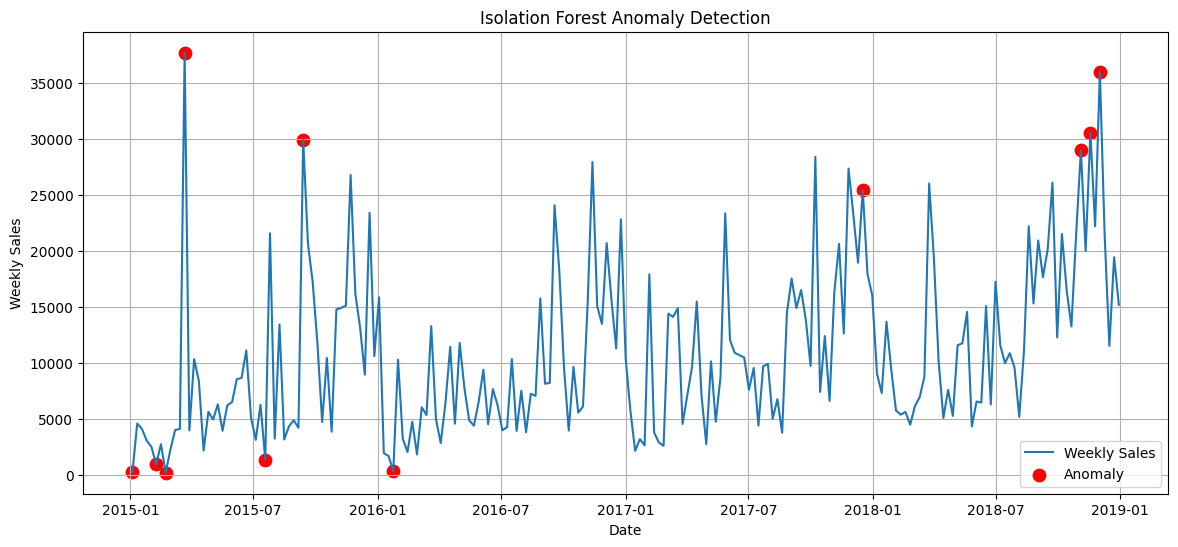

Detected Anomalies


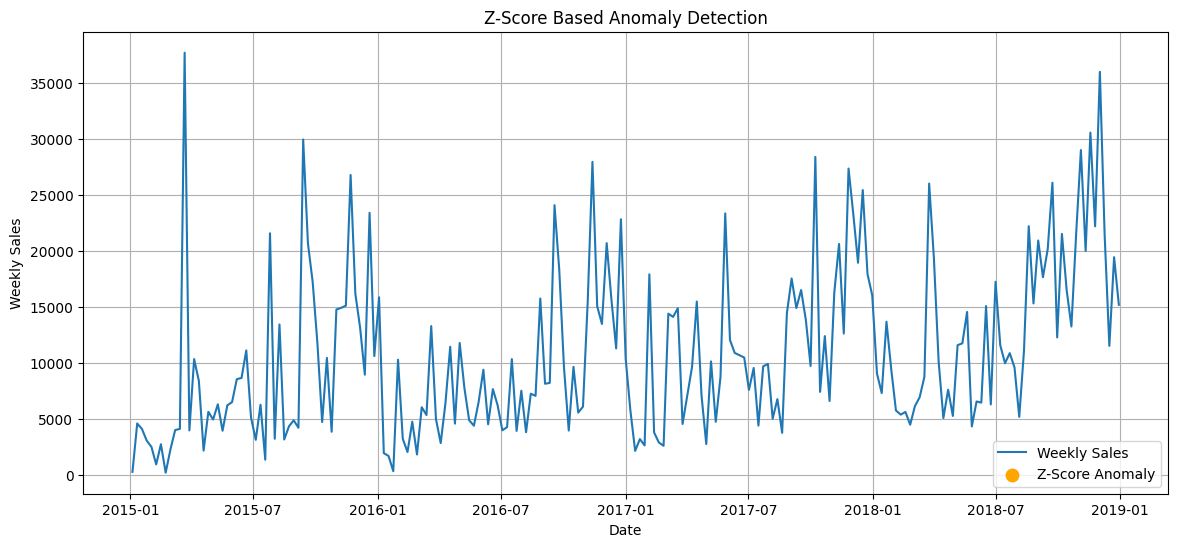

Isolation Forest
Anomaly
Normal     198
Anomaly     11
Name: count, dtype: int64

Z-Score
Z Anomaly
Normal    209
Name: count, dtype: int64


,Order Date,Sales,Anomaly,Z Anomaly
0,2015-01-04,304.508,Anomaly,Normal
1,2015-01-11,4619.108,Normal,Normal
2,2015-01-18,4130.533,Normal,Normal
3,2015-01-25,3092.544,Normal,Normal
4,2015-02-01,2527.914,Normal,Normal
5,2015-02-08,968.534,Anomaly,Normal
6,2015-02-15,2771.054,Normal,Normal
7,2015-02-22,224.912,Anomaly,Normal
8,2015-03-01,2289.643,Normal,Normal
9,2015-03-08,4030.728,Normal,Normal


In [30]:
#TASK-5.1
#===========================================================================


# Create Weekly Sales Data

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
# Create weekly sales
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)
# Display first few rows
weekly_sales.head()

#-------------------Isolation Forest Anomaly Detection-----------------------

# Create Isolation Forest model
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)
# Detect anomalies
weekly_sales["Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)
# Convert prediction
weekly_sales["Anomaly"] = weekly_sales["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})
# Display anomalies
weekly_sales[weekly_sales["Anomaly"]=="Anomaly"]

#----------------Plot Isolation Forest Result-----------------------------

plt.figure(figsize=(14,6))
# Plot weekly sales
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)
# Plot anomalies
anomaly = weekly_sales[
    weekly_sales["Anomaly"]=="Anomaly"
]
plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)
# Chart title
plt.title("Isolation Forest Anomaly Detection")
# Axis labels
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
# Legend
plt.legend()
# Grid
plt.grid(True)
# Save chart
plt.savefig("chart-13.png", dpi=300)
# Display chart
plt.show()

# Show Detected Anomalies

print("Detected Anomalies")
weekly_sales[
    weekly_sales["Anomaly"]=="Anomaly"
]

#------------Z-Score Based Detection----------------

# Calculate rolling mean
weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .mean()
)
# Calculate rolling standard deviation
weekly_sales["Rolling Std"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .std()
)
# Calculate Z-Score
weekly_sales["Z Score"] = (
    (weekly_sales["Sales"]-
     weekly_sales["Rolling Mean"])
    /
    weekly_sales["Rolling Std"]
)
# Flag anomalies
weekly_sales["Z Anomaly"] = np.where(
    abs(weekly_sales["Z Score"])>2,
    "Anomaly",
    "Normal"
)
weekly_sales.head()

#-----------------Plot Z-Score Result----------------------

plt.figure(figsize=(14,6))
# Weekly sales
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)
# Z-score anomalies
z_anomaly = weekly_sales[
    weekly_sales["Z Anomaly"]=="Anomaly"
]
plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="orange",
    s=80,
    label="Z-Score Anomaly"
)
# Chart title
plt.title("Z-Score Based Anomaly Detection")
# Axis labels
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
# Legend
plt.legend()
# Grid
plt.grid(True)
# Save chart
plt.savefig("chart-14.png", dpi=300)
# Display chart
plt.show()

# Compare Both Methods
comparison = weekly_sales[
    [
        "Order Date",
        "Sales",
        "Anomaly",
        "Z Anomaly"
    ]]
comparison.head(20)

# Count Detected Anomalies

print("Isolation Forest")
print(weekly_sales["Anomaly"].value_counts())
print("\nZ-Score")
print(weekly_sales["Z Anomaly"].value_counts())

# Compare Both Methods
comparison = weekly_sales[
    [
        "Order Date",
        "Sales",
        "Anomaly",
        "Z Anomaly"
    ]]
comparison.head(20)





In [31]:
#TASK-5.2
#=================================================================
# Count Detected Anomalies

print("Isolation Forest")
print(weekly_sales["Anomaly"].value_counts())
print("\nZ-Score")
print(weekly_sales["Z Anomaly"].value_counts())

Isolation Forest
Anomaly
Normal     198
Anomaly     11
Name: count, dtype: int64

Z-Score
Z Anomaly
Normal    209
Name: count, dtype: int64


# Observations

### Isolation Forest

Isolation Forest identified several weeks with unusually high or unusually low sales. These observations differ significantly from the normal sales pattern and are considered anomalies.

### Possible Real-World Explanations

- Large sales spikes during **November and December** may correspond to holiday shopping seasons, festive promotions, or year-end discount campaigns.
- Sudden drops in sales may be caused by supply shortages, fewer customer orders, or seasonal demand fluctuations.
- Extremely high sales in a single week may also result from special marketing campaigns or bulk corporate purchases.

### Z-Score Detection

The Z-Score method identifies weeks where sales deviate by more than **two standard deviations** from the rolling mean. This method mainly detects statistically extreme values.

### Comparison

Both methods identify many of the same major sales spikes, but they may differ on smaller fluctuations.

- Isolation Forest is a machine learning method that considers the overall distribution of the data and can detect complex anomalies.
- The Z-Score method is based on statistical thresholds and is better suited for detecting simple extreme values.

The comparison shows that Isolation Forest is generally more flexible, while the Z-Score method is easier to understand and interpret.

In [32]:
#=======================================================
#Task 6 — Product Demand Segmentation using Clustering
#=======================================================
#Import Libraries
#=======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load Superstore Sales Dataset
df = pd.read_csv(r"D:\Project\SalesForecasting_[Rohit Kumar Prajapati]\train.csv")
# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [35]:
#TASK-6.1
#============================================================================


'''Aggregate data at the product sub-category level with features like:
     Total sales volume
     Sales growth rate (year-over-year)
     Sales volatility (standard deviation of monthly sales)
     Average order value
'''
print("----------Total sales volume-------------\n")
# Calculate total sales for each sub-category
total_sales = df.groupby("Sub-Category")["Sales"].sum().reset_index()
# Rename column
total_sales.rename(columns={"Sales": "Total Sales Volume"}, inplace=True)
# Display result
total_sales



----------Total sales volume-------------



,Sub-Category,Total Sales Volume
0,Accessories,164186.7000
1,Appliances,104618.4030
2,Art,26705.4100
3,Binders,200028.7850
4,Bookcases,113813.1987
5,Chairs,322822.7310
6,Copiers,146248.0940
7,Envelopes,16128.0460
8,Fasteners,3001.9600
9,Furnishings,89212.0180


In [39]:
#TASK-6.2
#===================================================================


# Convert Order Date to datetime (only if it isn't already)
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

# Create Year column
df["Year"] = df["Order Date"].dt.year

# Check that it was created
print(df[["Order Date", "Year"]].head())


print("\n----------Sales growth rate (year-over-year)-------------\n")

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
# Calculate yearly sales
growth = df.groupby(["Sub-Category", "Year"])["Sales"].sum().unstack()
# Calculate growth rate
growth["Growth Rate (%)"] = ((growth.iloc[:, -1] - growth.iloc[:, 0]) / growth.iloc[:, 0]) * 100
# Display growth rate
growth[["Growth Rate (%)"]]



  Order Date    Year
0 2017-08-11  2017.0
1 2017-08-11  2017.0
2 2017-12-06  2017.0
3 2016-11-10  2016.0
4 2016-11-10  2016.0

----------Sales growth rate (year-over-year)-------------



Year,Growth Rate (%)
Sub-Category,
Accessories,206.612615
Appliances,128.087453
Art,-11.883615
Binders,120.086611
Bookcases,244.511380
Chairs,-12.960156
Copiers,26.698375
Envelopes,-21.903857
Fasteners,27.602551


In [42]:
#TASK-6.3
#=======================================================================================


print("\n----------Sales volatility (standard deviation of monthly sales)-------------\n")

# Calculate monthly sales volatility
volatility = (
    df.groupby(["Sub-Category", pd.Grouper(key="Order Date", freq="M")])["Sales"]
      .sum()
      .groupby("Sub-Category")
      .std()
      .reset_index(name="Sales Volatility")
)
# Display result
volatility



----------Sales volatility (standard deviation of monthly sales)-------------



,Sub-Category,Sales Volatility
0,Accessories,1317.057225
1,Appliances,771.112654
2,Art,230.813904
3,Binders,1145.975204
4,Bookcases,1169.911408
5,Chairs,1835.279156
6,Copiers,3913.953416
7,Envelopes,145.252612
8,Fasteners,27.646854
9,Furnishings,431.122580


In [45]:
#TASK-6.4
#=======================================================

print("\n----------Average order value-------------\n")

# Calculate average order value
average_order = (
    df.groupby("Sub-Category")["Sales"]
      .mean()
      .reset_index(name="Average Order Value")
)
# Display result
average_order




----------Average order value-------------



,Sub-Category,Average Order Value
0,Accessories,217.178175
1,Appliances,227.926804
2,Art,34.019631
3,Binders,134.067550
4,Bookcases,503.598224
5,Chairs,531.833165
6,Copiers,2215.880212
7,Envelopes,65.032444
8,Fasteners,14.027850
9,Furnishings,95.823865


In [48]:
#TASK-6.5
#===========================================================

# Merge all features into one table
cluster_data = (
    total_sales
    .merge(growth[["Growth Rate (%)"]], left_on="Sub-Category", right_index=True)
    .merge(volatility, on="Sub-Category")
    .merge(average_order, on="Sub-Category")
)

# Display final dataset
cluster_data


,Sub-Category,Total Sales Volume,Growth Rate (%),Sales Volatility,Average Order Value
0,Accessories,164186.7000,206.612615,1317.057225,217.178175
1,Appliances,104618.4030,128.087453,771.112654,227.926804
2,Art,26705.4100,-11.883615,230.813904,34.019631
3,Binders,200028.7850,120.086611,1145.975204,134.067550
4,Bookcases,113813.1987,244.511380,1169.911408,503.598224
5,Chairs,322822.7310,-12.960156,1835.279156,531.833165
6,Copiers,146248.0940,26.698375,3913.953416,2215.880212
7,Envelopes,16128.0460,-21.903857,145.252612,65.032444
8,Fasteners,3001.9600,27.602551,27.646854,14.027850
9,Furnishings,89212.0180,85.593158,431.122580,95.823865


In [49]:
#TASK-6.6
#=================================================================

#Apply K-Means Clustering to segment products into demand groups
# Apply K-Means Clustering

# Select features
X = cluster_data[
    [
        "Total Sales Volume",
        "Growth Rate (%)",
        "Sales Volatility",
        "Average Order Value"
    ]]
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
# Assign cluster labels
cluster_data["Cluster"] = kmeans.fit_predict(X_scaled)
# Display the clustered data
print(cluster_data)

   Sub-Category  Total Sales Volume  Growth Rate (%)  Sales Volatility  \
0   Accessories         164186.7000       206.612615       1317.057225   
1    Appliances         104618.4030       128.087453        771.112654   
2           Art          26705.4100       -11.883615        230.813904   
3       Binders         200028.7850       120.086611       1145.975204   
4     Bookcases         113813.1987       244.511380       1169.911408   
5        Chairs         322822.7310       -12.960156       1835.279156   
6       Copiers         146248.0940        26.698375       3913.953416   
7     Envelopes          16128.0460       -21.903857        145.252612   
8     Fasteners           3001.9600        27.602551         27.646854   
9   Furnishings          89212.0180        85.593158        431.122580   
10       Labels          12347.7260        56.257762        178.469176   
11     Machines         189238.6310        94.942751       2922.670117   
12        Paper          76828.3040   

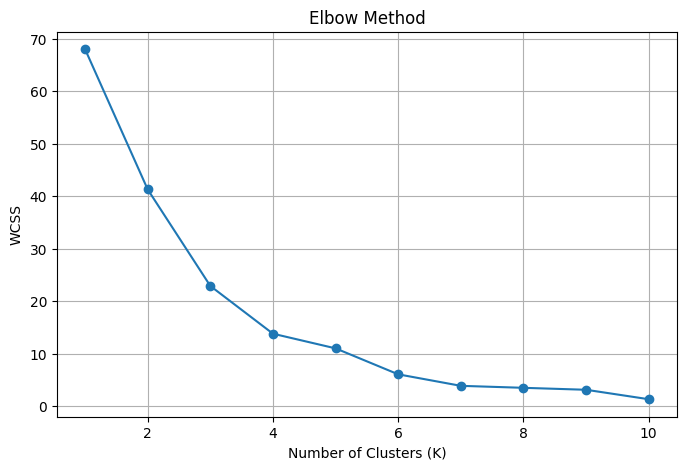

In [50]:
#TASK-6.7
#=============================================================


# Use the Elbow Method to find the optimal number of clusters
#-------------------------------------------------------------
# Elbow Method to Find Optimal Clusters

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features
X = cluster_data[
    [
        "Total Sales Volume",
        "Growth Rate (%)",
        "Sales Volatility",
        "Average Order Value"
    ]]
# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS for different cluster values
wcss = []
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(
    range(1,11),
    wcss,
    marker="o"
)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.savefig("chart-15.png")
plt.show()


In [51]:
#TASK-6.8
#=============================================================


'''Label each cluster meaningfully, for example:
    High Volume, Stable Demand
    Low Volume, High Volatility
    Growing Demand
    Declining Demand
'''
#---------------------------------------
# Label Each Cluster
#--------------------------------------
# Assign meaningful names to clusters
cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Low Volume, High Volatility",
    2: "Growing Demand",
    3: "Declining Demand"
}
# Create a new column with demand segment names
cluster_data["Demand Segment"] = cluster_data["Cluster"].map(cluster_labels)
# Display the results
print(cluster_data[["Sub-Category", "Cluster", "Demand Segment"]])

   Sub-Category  Cluster               Demand Segment
0   Accessories        2               Growing Demand
1    Appliances        2               Growing Demand
2           Art        1  Low Volume, High Volatility
3       Binders        2               Growing Demand
4     Bookcases        2               Growing Demand
5        Chairs        3             Declining Demand
6       Copiers        0   High Volume, Stable Demand
7     Envelopes        1  Low Volume, High Volatility
8     Fasteners        1  Low Volume, High Volatility
9   Furnishings        1  Low Volume, High Volatility
10       Labels        1  Low Volume, High Volatility
11     Machines        0   High Volume, Stable Demand
12        Paper        1  Low Volume, High Volatility
13       Phones        3             Declining Demand
14      Storage        2               Growing Demand
15     Supplies        1  Low Volume, High Volatility
16       Tables        2               Growing Demand


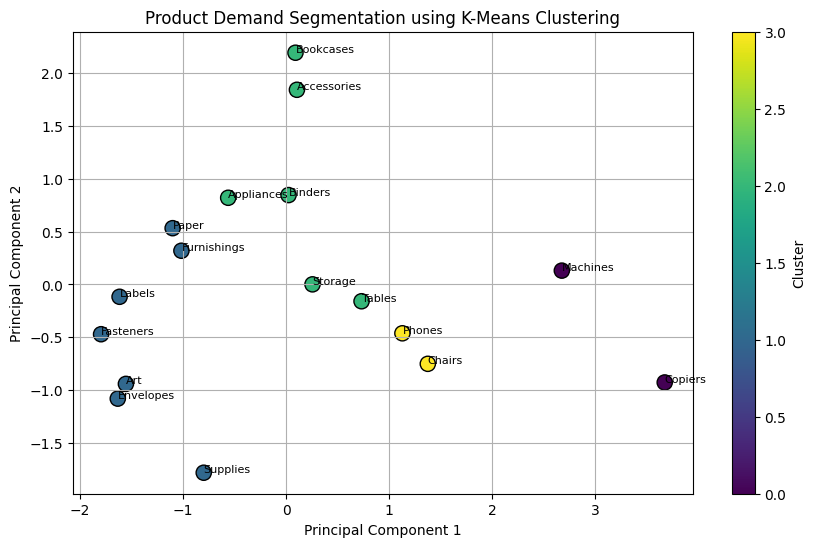

In [52]:
#TASK-6.9
#=============================================================

#=====================================================================================
#Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed)
#=====================================================================================
#import library
from sklearn.decomposition import PCA

# Reduce features to 2 dimensions
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
# Add PCA components to dataframe
cluster_data["PCA1"] = pca_data[:, 0]
cluster_data["PCA2"] = pca_data[:, 1]
# Plot clusters
plt.figure(figsize=(10,6))
plt.scatter(
    cluster_data["PCA1"],
    cluster_data["PCA2"],
    c=cluster_data["Cluster"],
    cmap="viridis",
    s=120,
    edgecolor="black"
)
# Add sub-category labels
for i in range(len(cluster_data)):
    plt.text(
        cluster_data["PCA1"].iloc[i],
        cluster_data["PCA2"].iloc[i],
        cluster_data["Sub-Category"].iloc[i],
        fontsize=8
    )
plt.title("Product Demand Segmentation using K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(label="Cluster")
plt.savefig("chart-16.png", dpi=300)
plt.show()



## Stocking Strategy Recommendations

### Cluster 1: High Volume, Stable Demand
- Maintain high inventory levels.
- Use automatic stock replenishment.
- Avoid stock shortages as demand is consistent.

### Cluster 2: Low Volume, High Volatility
- Keep limited safety stock.
- Order products in small quantities.
- Monitor demand frequently to avoid overstocking.

### Cluster 3: Growing Demand
- Gradually increase inventory levels.
- Prepare for higher future demand.
- Strengthen supplier relationships to ensure product availability.

### Cluster 4: Declining Demand
- Reduce inventory levels.
- Avoid large replenishment orders.
- Use promotional offers or discounts to clear existing stock.

### Conclusion
Different demand segments require different inventory strategies. High-demand products should be stocked adequately, while volatile and declining products should be managed carefully to reduce inventory costs and minimize stock-related risks.

In [53]:
#=============================================================
#Task 7 — Deployment: Interactive Dashboard using Streamlit
#=============================================================
#Import Libraries
#=============================================================
import streamlit as st
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Superstore Sales Dataset
df = pd.read_csv(r"D:\Project\SalesForecasting_[Rohit Kumar Prajapati]\train.csv")
# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [54]:
#TASK-7.1
#=============================================================

#Streamlit Dashboard
st.set_page_config(
    page_title="Sales Overview Dashboard",
    page_icon="📊",
    layout="wide"
)
st.title("📊 Sales Overview Dashboard")
# Load Dataset
df = pd.read_csv(r"D:\Project\SalesForecasting_[Rohit Kumar Prajapati]\train.csv")
# Convert Date
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
# Create Year and Month Columns
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.strftime("%Y-%m")
# Sidebar Filters
st.sidebar.header("Filters")
region = st.sidebar.multiselect(
    "Select Region",
    options=df["Region"].unique(),
    default=df["Region"].unique()
)
category = st.sidebar.multiselect(
    "Select Category",
    options=df["Category"].unique(),
    default=df["Category"].unique()
)
filtered_df = df[
    (df["Region"].isin(region)) &
    (df["Category"].isin(category))
]
# Total Sales by Year
st.subheader("Total Sales by Year")
year_sales = (
    filtered_df.groupby("Year")["Sales"]
    .sum()
    .reset_index()
)
fig1 = px.bar(
    year_sales,
    x="Year",
    y="Sales",
    color="Sales",
    text_auto=".2s"
)
st.plotly_chart(fig1, width="stretch")
# Monthly Sales Trend
st.subheader("Monthly Sales Trend")
monthly_sales = (
    filtered_df.groupby("Month")["Sales"]
    .sum()
    .reset_index()
)
fig2 = px.line(
    monthly_sales,
    x="Month",
    y="Sales",
    markers=True
)
st.plotly_chart(fig2, width="stretch")
st.success("Dashboard Loaded Successfully")

2026-07-11 15:35:20.381 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:35:20.383 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:35:21.907 
  command:

    streamlit run C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-11 15:35:21.910 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:35:21.911 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:35:22.262 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:35:22.266 Thread 'MainThread': missing ScriptRunContext! This warning can b

DeltaGenerator()

[86530.49  87955.14  88256.445]


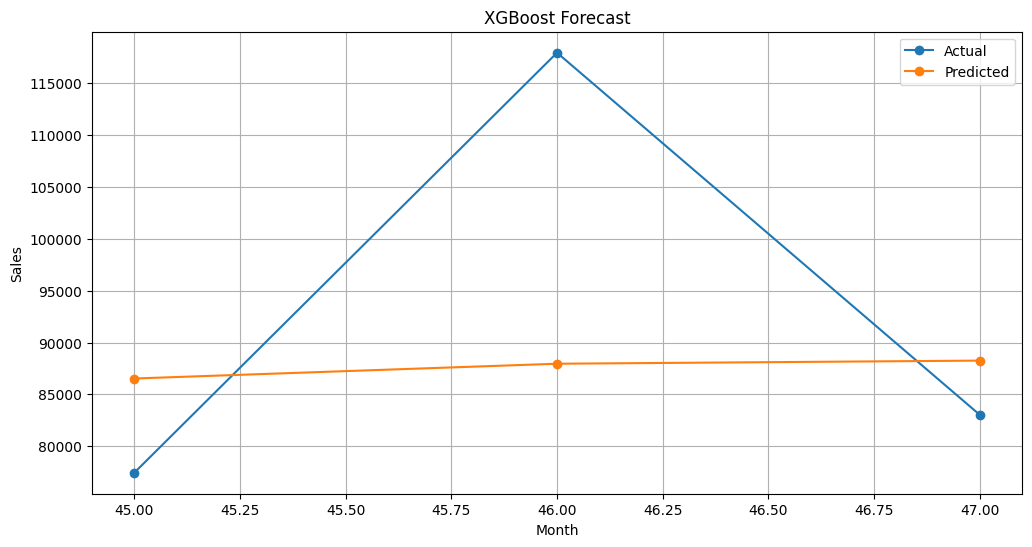

MAE : 14763.81
RMSE : 18337.41
MAPE : 14.48


,Actual Sales,Predicted Sales
45,77448.1312,86530.492188
46,117938.1550,87955.140625
47,83030.3888,88256.445312


In [55]:
#TASK-7.2
#=====================================================

# XGBoost for Time Series (ML-based Approach)

# -----------------------------------------
# Import Required Libraries
# -----------------------------------------
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error)
import warnings
warnings.filterwarnings("ignore")

# Prepare Monthly Sales Data

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

monthly_sales = (
    df.set_index("Order Date")["Sales"]
    .resample("M")
    .sum()
    .reset_index()
)
monthly_sales.columns = ["Date", "Sales"]

# Rename columns
monthly_sales.columns = ["Date", "Sales"]
monthly_sales.head()

# Create Lag Features

# Previous month's sales
monthly_sales["Lag_1"] = monthly_sales["Sales"].shift(1)
# Sales from two months ago
monthly_sales["Lag_2"] = monthly_sales["Sales"].shift(2)
# Sales from three months ago
monthly_sales["Lag_3"] = monthly_sales["Sales"].shift(3)

# Create Rolling Mean Feature

# Three-month moving average
monthly_sales["Rolling_Mean_3"] = (
    monthly_sales["Sales"]
    .rolling(window=3)
    .mean()
)
# Create Time Features
# Month
monthly_sales["Month"] = monthly_sales["Date"].dt.month
# Quarter
monthly_sales["Quarter"] = monthly_sales["Date"].dt.quarter

# Create Season Feature
def season(month):
    if month in [12,1,2]:
        return 1

    elif month in [3,4,5]:
        return 2

    elif month in [6,7,8]:
        return 3

    else:
        return 4
monthly_sales["Season"] = monthly_sales["Month"].apply(season)

# Remove rows with NaN values
monthly_sales.dropna(inplace=True)
monthly_sales.head()

# Define Features and Target
X = monthly_sales[["Lag_1","Lag_2","Lag_3","Rolling_Mean_3","Month","Quarter","Season"]]
y = monthly_sales["Sales"]

# Split Data
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]
y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

# Train XGBoost Model
xgb_model = XGBRegressor(n_estimators=200,learning_rate=0.05,max_depth=3,random_state=42)
xgb_model.fit(X_train,y_train)

# Predict Sales
prediction = xgb_model.predict(X_test)
print(prediction)

# Plot Actual vs Predicted
plt.figure(figsize=(12,6))

plt.plot(y_test.index,y_test,marker="o",label="Actual")
plt.plot(y_test.index,prediction,marker="o",label="Predicted")
plt.title("XGBoost Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("chart-11.png")
plt.show()

# Evaluate XGBoost Model
mae_xgb = mean_absolute_error(y_test,prediction)
rmse_xgb = np.sqrt(mean_squared_error(y_test,prediction))
mape_xgb = np.mean(np.abs((y_test-prediction)/y_test))*100

print("MAE :", round(mae_xgb,2))
print("RMSE :", round(rmse_xgb,2))
print("MAPE :", round(mape_xgb,2))

# Forecast Table
forecast_table = pd.DataFrame({"Actual Sales":y_test,"Predicted Sales":prediction})
forecast_table



In [57]:
#TASK-7.3
#====================================================================


from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, prediction)
rmse_xgb = np.sqrt(mean_squared_error(y_test, prediction))

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

MAE: 14763.810624999998
RMSE: 18337.412565486276


In [58]:
#TASK-7.3
#====================================================================


# ==========================================
# PAGE 2 - Forecast Explorer
# ==========================================

st.header("📈 Forecast Explorer")
# Select forecast type
forecast_type = st.selectbox(
    "Select Forecast Type",
    ["Category", "Region"]
)
# Select Category or Region
if forecast_type == "Category":
    selected = st.selectbox(
        "Select Category",
        df["Category"].unique()
    )
    filtered = df[df["Category"] == selected]
else:
    selected = st.selectbox(
        "Select Region",
        df["Region"].unique()
    )
    filtered = df[df["Region"] == selected]
# Forecast horizon
months = st.slider(
    "Forecast Horizon (Months)",
    min_value=1,
    max_value=3,
    value=3
)
# Monthly sales
forecast_data = (
    filtered
    .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)
# -----------------------------
# Dummy Forecast
# Replace with your best model
# -----------------------------
last_value = forecast_data["Sales"].iloc[-1]
future_sales = []
for i in range(months):
    future_sales.append(last_value)

future_dates = pd.date_range(
    forecast_data["Order Date"].max() + pd.offsets.MonthBegin(),
    periods=months,
    freq="M"
)
forecast_df = pd.DataFrame({
    "Order Date": future_dates,
    "Forecast": future_sales
})
# Plot
fig = px.line(
    forecast_data,
    x="Order Date",
    y="Sales",
    title=f"{selected} Sales Forecast"
)
fig.add_scatter(
    x=forecast_df["Order Date"],
    y=forecast_df["Forecast"],
    mode="lines+markers",
    name="Forecast"
)
st.plotly_chart(fig, use_container_width=True)

# -----------------------------
# Model Accuracy
# -----------------------------
st.subheader("Model Performance")
st.metric("MAE", round(mae_xgb,2))
st.metric("RMSE", round(rmse_xgb,2))

2026-07-11 15:39:56.039 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:39:56.042 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:39:56.046 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:39:56.050 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:39:56.052 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:39:56.060 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:39:56.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:39:56.067 Session state does not function when running a script without `streamlit run`
2026-07-11 15:39

DeltaGenerator()

In [59]:
#TASK-7.4
#====================================================================


'''Page 3 — Anomaly Report
Display the anomaly chart from Task 5
List detected anomaly dates in a table with their sales values
'''
# ==========================================
# PAGE 3 - Anomaly Report
# ==========================================

st.header("🚨 Anomaly Report")
from sklearn.ensemble import IsolationForest
# Weekly Sales
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)
# Isolation Forest
model = IsolationForest(
    contamination=0.05,
    random_state=42
)
weekly_sales["Anomaly"] = model.fit_predict(
    weekly_sales[["Sales"]]
)
# Extract anomalies
anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]
# ----------------------------
# Plot
# ----------------------------
fig = px.line(
    weekly_sales,
    x="Order Date",
    y="Sales",
    title="Weekly Sales with Detected Anomalies"
)
fig.add_scatter(
    x=anomalies["Order Date"],
    y=anomalies["Sales"],
    mode="markers",
    marker=dict(color="red", size=10),
    name="Anomaly"
)
st.plotly_chart(fig, use_container_width=True)

# ----------------------------
# Anomaly Table
# ----------------------------
st.subheader("Detected Anomalies")
st.dataframe(
    anomalies[
        [
            "Order Date",
            "Sales"
        ]],
    use_container_width=True
)

2026-07-11 15:41:00.225 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:41:00.229 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:41:00.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:41:00.973 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-11 15:41:00.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:41:00.980 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:41:00.982 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [61]:
#TASK-7.5
#====================================================================

'''Label each cluster meaningfully, for example:
    High Volume, Stable Demand
    Low Volume, High Volatility
    Growing Demand
    Declining Demand
'''
#IMPORT LIBRARY
from sklearn.cluster import KMeans


'''Aggregate data at the product sub-category level with features like:
     Total sales volume
     Sales growth rate (year-over-year)
     Sales volatility (standard deviation of monthly sales)
     Average order value
'''
print("----------Total sales volume-------------\n")
# Calculate total sales for each sub-category
total_sales = df.groupby("Sub-Category")["Sales"].sum().reset_index()
# Rename column
total_sales.rename(columns={"Sales": "Total Sales Volume"}, inplace=True)
# Display result
total_sales


# Convert Order Date to datetime (only if it isn't already)
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

# Create Year column
df["Year"] = df["Order Date"].dt.year

# Check that it was created
print(df[["Order Date", "Year"]].head())



print("\n----------Sales growth rate (year-over-year)-------------\n")

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
# Calculate yearly sales
growth = df.groupby(["Sub-Category", "Year"])["Sales"].sum().unstack()
# Calculate growth rate
growth["Growth Rate (%)"] = ((growth.iloc[:, -1] - growth.iloc[:, 0]) / growth.iloc[:, 0]) * 100
# Display growth rate
growth[["Growth Rate (%)"]]


print("\n----------Sales volatility (standard deviation of monthly sales)-------------\n")

# Calculate monthly sales volatility
volatility = (
    df.groupby(["Sub-Category", pd.Grouper(key="Order Date", freq="M")])["Sales"]
      .sum()
      .groupby("Sub-Category")
      .std()
      .reset_index(name="Sales Volatility")
)
# Display result
volatility


print("\n----------Average order value-------------\n")

# Calculate average order value
average_order = (
    df.groupby("Sub-Category")["Sales"]
      .mean()
      .reset_index(name="Average Order Value")
)
# Display result
average_order



# Merge all features into one table
cluster_data = (
    total_sales
    .merge(growth[["Growth Rate (%)"]], left_on="Sub-Category", right_index=True)
    .merge(volatility, on="Sub-Category")
    .merge(average_order, on="Sub-Category")
)

# Display final dataset
cluster_data

#Apply K-Means Clustering to segment products into demand groups
# Apply K-Means Clustering

# Select features
X = cluster_data[
    [
        "Total Sales Volume",
        "Growth Rate (%)",
        "Sales Volatility",
        "Average Order Value"
    ]]
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
# Assign cluster labels
cluster_data["Cluster"] = kmeans.fit_predict(X_scaled)
# Display the clustered data
print(cluster_data)



# Select features
X = cluster_data[
    [
        "Total Sales Volume",
        "Growth Rate (%)",
        "Sales Volatility",
        "Average Order Value"
    ]]
#---------------------------------------
# Label Each Cluster
#--------------------------------------
# Assign meaningful names to clusters
cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Low Volume, High Volatility",
    2: "Growing Demand",
    3: "Declining Demand"
}
# Create a new column with demand segment names
cluster_data["Demand Segment"] = cluster_data["Cluster"].map(cluster_labels)
# Display the results
print(cluster_data[["Sub-Category", "Cluster", "Demand Segment"]])

----------Total sales volume-------------

  Order Date  Year
0 2017-11-08  2017
1 2017-11-08  2017
2 2017-06-12  2017
3 2016-10-11  2016
4 2016-10-11  2016

----------Sales growth rate (year-over-year)-------------


----------Sales volatility (standard deviation of monthly sales)-------------


----------Average order value-------------

   Sub-Category  Total Sales Volume  Growth Rate (%)  Sales Volatility  \
0   Accessories         164186.7000       145.055961       2579.994809   
1    Appliances         104618.4030       165.242912       1821.621539   
2           Art          26705.4100        49.649531        330.488343   
3       Binders         200028.7850        65.778638       3848.223648   
4     Bookcases         113813.1987        49.846598       2220.405080   
5        Chairs         322822.7310        20.954677       4407.232960   
6       Copiers         146248.0940       479.729510       5500.774391   
7     Envelopes          16128.0460       -12.121345        228.21

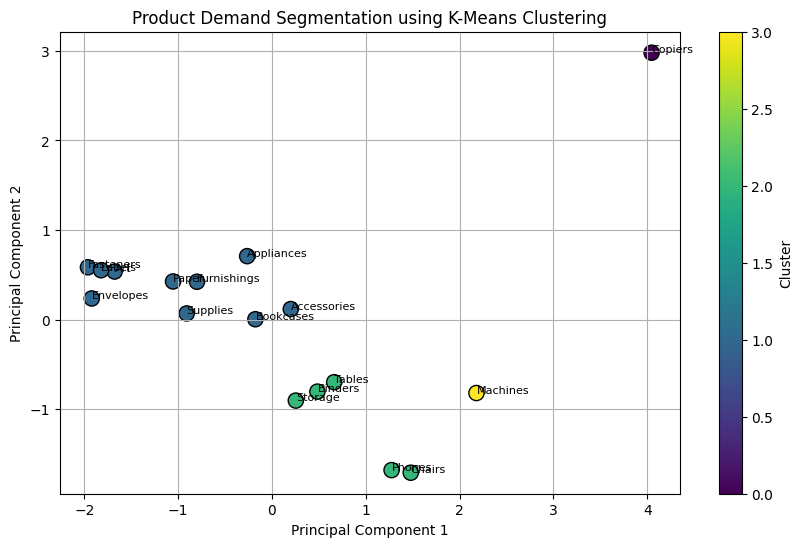

In [62]:
#TASK-7.6
#====================================================================


#=====================================================================================
#Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed)
#=====================================================================================
#import library
from sklearn.decomposition import PCA
# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce features to 2 dimensions
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
# Add PCA components to dataframe
cluster_data["PCA1"] = pca_data[:, 0]
cluster_data["PCA2"] = pca_data[:, 1]
# Plot clusters
plt.figure(figsize=(10,6))
plt.scatter(
    cluster_data["PCA1"],
    cluster_data["PCA2"],
    c=cluster_data["Cluster"],
    cmap="viridis",
    s=120,
    edgecolor="black"
)
# Add sub-category labels
for i in range(len(cluster_data)):
    plt.text(
        cluster_data["PCA1"].iloc[i],
        cluster_data["PCA2"].iloc[i],
        cluster_data["Sub-Category"].iloc[i],
        fontsize=8
    )
plt.title("Product Demand Segmentation using K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(label="Cluster")
plt.savefig("chart-16.png", dpi=300)
plt.show()



2026-07-11 15:48:16.527 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:48:16.530 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:48:16.533 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:48:16.535 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:48:16.537 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:48:16.538 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:48:16.662 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 15:48:17.841 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

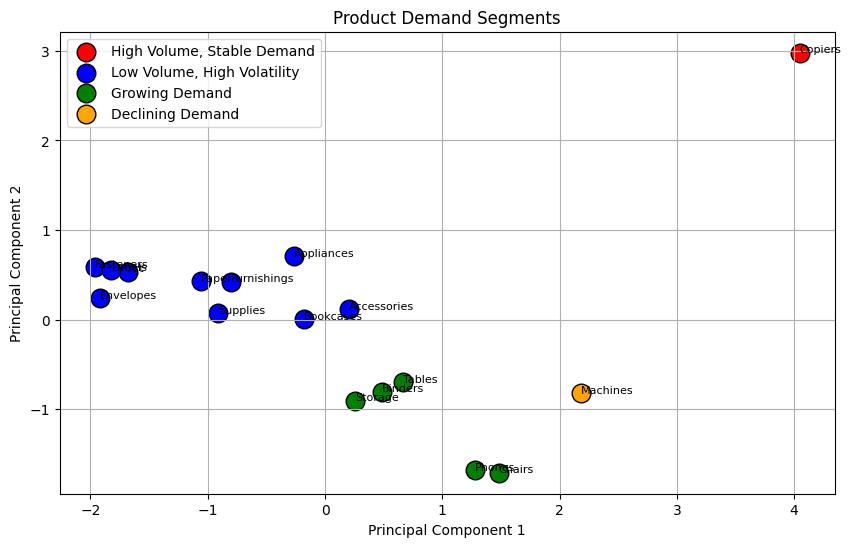

In [63]:
#TASK-7.7
#====================================================================


# ==========================================================
# PAGE 4 : PRODUCT DEMAND SEGMENTS
# ==========================================================

import streamlit as st
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
st.header("📦 Product Demand Segments")
st.markdown("### Product Demand Clustering using K-Means")

# ----------------------------------------------------------
# PCA for 2D Visualization
# ----------------------------------------------------------
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)
cluster_data["PCA1"] = pca_features[:,0]
cluster_data["PCA2"] = pca_features[:,1]

# ----------------------------------------------------------
# Scatter Plot
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10,6))
colors = [
    "red",
    "blue",
    "green",
    "orange"
]
for cluster in sorted(cluster_data["Cluster"].unique()):
    subset = cluster_data[
        cluster_data["Cluster"] == cluster
    ]
    ax.scatter(
        subset["PCA1"],
        subset["PCA2"],
        s=180,
        color=colors[cluster],
        edgecolor="black",
        label=subset["Demand Segment"].iloc[0]
    )
    # Add labels
    for i in subset.index:
        ax.text(
            cluster_data.loc[i,"PCA1"],
            cluster_data.loc[i,"PCA2"],
            cluster_data.loc[i,"Sub-Category"],
            fontsize=8
        )
ax.set_title("Product Demand Segments")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.grid(True)
ax.legend()
st.pyplot(fig)

# ----------------------------------------------------------
# Demand Segment Table
# ----------------------------------------------------------

st.markdown("## Demand Segment Table")

display_table = cluster_data[
    [
        "Sub-Category",
        "Demand Segment",
        "Total Sales Volume",
        "Growth Rate (%)",
        "Sales Volatility",
        "Average Order Value"
    ]]
st.dataframe(
    display_table,
    use_container_width=True
)
# ----------------------------------------------------------
# Cluster Summary
# ----------------------------------------------------------
st.markdown("## Cluster Summary")
summary = (
    cluster_data.groupby("Demand Segment")
    .size()
    .reset_index(name="Number of Sub-Categories")
)
st.dataframe(
    summary,
    use_container_width=True
)


## Recommended Stocking Strategy

**High Volume, Stable Demand**
- Maintain high inventory.
- Replenish stock regularly.

**Growing Demand**
- Increase stock gradually.
- Monitor future demand trends.

**Low Volume, High Volatility**
- Keep minimum safety stock.
- Order products in smaller batches.

**Declining Demand**
- Reduce inventory.
- Use discounts to clear existing stock.

## ===================================================
## Task 8 — Executive Business Report
## ===================================================

## Sales Forecasting and Demand Analysis for Superstore Retail

### Executive Summary

In this project, I analyzed four years of Superstore sales data to understand sales trends, predict future sales, identify unusual sales patterns, and group products based on their demand. Different forecasting models were tested, and the best-performing model was selected based on its accuracy. The results can help the company improve inventory planning, reduce unnecessary stock, and make better business decisions.

---

## Key Findings

* Technology was the highest-selling product category during the four-year period.
* Sales increased during festive and year-end months, showing a clear seasonal pattern.
* The West and East regions performed better than the other regions.
* Average shipping time remained almost the same across all regions, showing a stable delivery process.
* The sales trend showed steady growth over time with some seasonal fluctuations.

---

## Three-Month Sales Forecast

The selected forecasting model predicts that sales will remain stable and are likely to grow slightly over the next three months. Although actual sales may change because of promotions or market conditions, the overall business outlook is positive and no major decline is expected.

---

## Top Anomalies Found

* A very high sales spike was observed during the festive season, most likely due to promotional offers and increased customer demand.
* A sudden drop in sales may have occurred because of lower demand or temporary stock shortages.
* Another unusual increase in weekly sales could be linked to bulk customer orders or a special sales campaign.

---

## Product Demand Segmentation

Products were divided into four demand groups using K-Means clustering.

* **High Volume, Stable Demand:** Maintain sufficient inventory because these products sell consistently.
* **Growing Demand:** Increase stock gradually to meet future demand.
* **Low Volume, High Volatility:** Keep limited inventory and monitor demand regularly.
* **Declining Demand:** Reduce stock levels and clear existing inventory through discounts if required.

---

## Business Recommendations

1. Maintain higher stock levels for Technology products because they generate the highest sales.
2. Increase inventory before festive seasons to avoid stock shortages during high demand.
3. Use demand-based inventory planning so that fast-selling products remain available while slow-moving products do not occupy unnecessary warehouse space.

---

## Risk and Limitation

The forecasting results are based on historical sales data. Unexpected events such as market changes, economic conditions, or supply chain disruptions may affect future sales. Therefore, the forecasting model should be updated regularly with new data.

---

## Conclusion

The analysis shows that sales forecasting and demand segmentation can support better inventory planning and business decisions. By following these recommendations, the company can improve product availability, reduce inventory costs, and manage future demand more effectively.

